## **Population and sample regression analysis**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# generating random data

n = 1000
alpha = 2.2
beta = 0.6
sigma = 1.5 # std of the disturbance 

x = np.random.uniform(1, 10, n)
epsilon = np.random.normal(0, sigma, n)
y = alpha + beta * x + epsilon

In [4]:
x_bar = np.mean(x)
y_bar = np.mean(y)

beta_hat = np.sum((x - x_bar) * (y - y_bar))/np.sum((x - x_bar)**2)
alpha_hat = y_bar - (beta_hat * x_bar)

print(f"True beta: {beta}, Estimated beta: {beta_hat:.4f}")
print(f"True alpha: {alpha}, Estimated alpha: {alpha_hat:.4f}")

True beta: 0.6, Estimated beta: 0.5897
True alpha: 2.2, Estimated alpha: 2.2124


In [5]:
# compute The RSS

y_hat = alpha_hat + beta_hat * x
residuals = y - y_hat
RSS = np.sum(residuals**2)

In [6]:
var_biased = RSS / n
var_unbiased = RSS / (n - 2)

In [7]:
var_x = np.sum((x - x_bar)**2)
sum_x_sq = np.sum(x**2)

In [8]:
SE_beta = np.sqrt(var_unbiased / var_x)
SE_alpha = np.sqrt((var_unbiased * sum_x_sq )/(n * var_x))

In [9]:
print(f"Biased variance: {var_biased:.4f}")
print(f"Unbiased variance: {var_unbiased:.4f}")
print(f"SE(beta): {SE_beta:.4f}")
print(f"SE(alpha): {SE_alpha:.4f}")

Biased variance: 2.2060
Unbiased variance: 2.2104
SE(beta): 0.0181
SE(alpha): 0.1094


In [90]:
# Sampling
n_s = 20
sample_idx = np.random.choice(n , size=n_s, replace=False)
x_s = x[sample_idx]
y_s = y[sample_idx]

In [91]:
x_bar_s = np.sum(x_s) / len(x_s)
y_bar_s = np.sum(y_s) / len(y_s)
beta_hat_s = np.sum((x_s - x_bar_s) * (y_s - y_bar_s))/ np.sum((x_s - x_bar_s)**2)
alpha_hat_s = y_bar_s - beta_hat_s * x_bar_s

In [92]:
y_hat_s = alpha_hat_s + beta_hat_s * x_s
residuals_s = y_s - y_hat_s
RSS_s = np.sum(residuals_s**2)

In [93]:
var_biased_s = RSS_s / n_s
var_unbiased_s = RSS_s / (n_s - 2)

In [94]:
var_x_s = np.sum((x_s - x_bar_s)**2)
sum_x_sq_s = np.sum(x_s**2)

In [95]:
SE_beta_s = np.sqrt(var_unbiased_s / var_x_s)
SE_alpha_s = np.sqrt((var_unbiased_s * sum_x_sq_s )/(n_s * var_x_s))

In [96]:
print(f"Biased variance: population={var_biased:.4f}, sample={var_biased_s:.4f}")
print(f"Unbiased variance: population={var_unbiased:.4f}, sample={var_unbiased_s:.4f}")
print(f"SE(beta): population={SE_beta:.4f}, sample={SE_beta_s:.4f}")
print(f"SE(alpha): population={SE_alpha:.4f}, sample={SE_alpha_s:.4f}")

Biased variance: population=2.2060, sample=1.6668
Unbiased variance: population=2.2104, sample=1.8519
SE(beta): population=0.0181, sample=0.1056
SE(alpha): population=0.1094, sample=0.7084


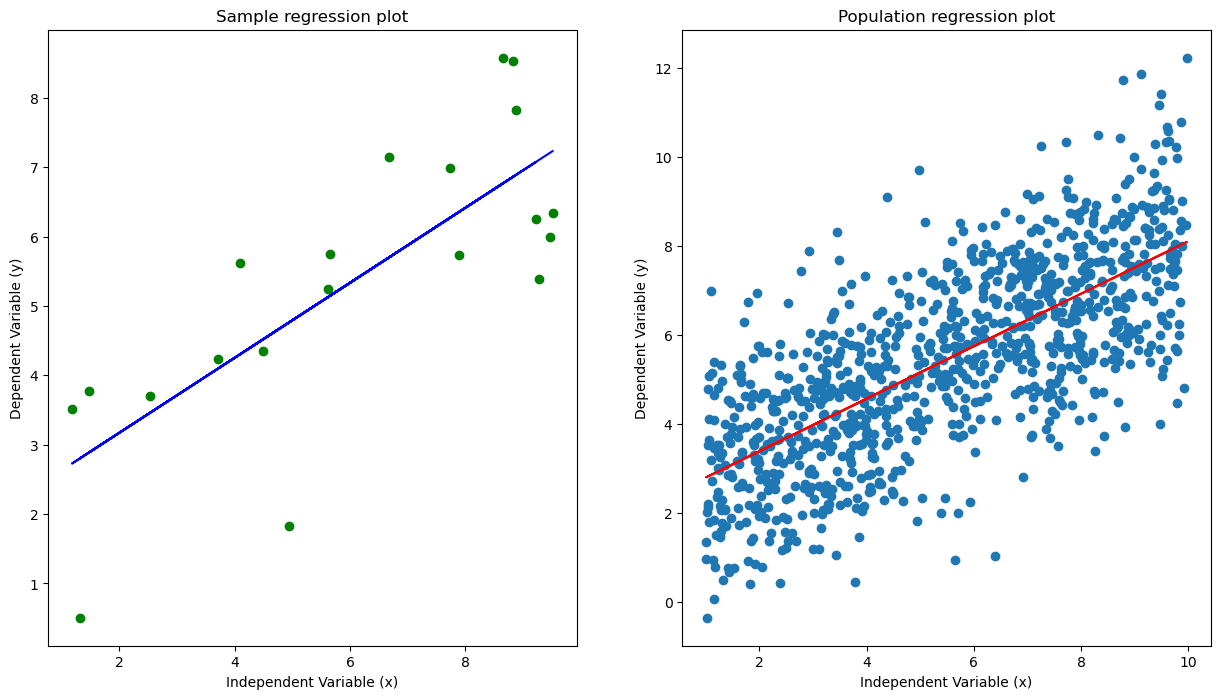

In [97]:
plt.figure(figsize=(15,8))
plt.subplot(121)
plt.scatter(x_s, y_s, c="g")
plt.plot(x_s, y_hat_s, "b-")
plt.xlabel("Independent Variable (x)")
plt.ylabel("Dependent Variable (y)")
plt.title("Sample regression plot")
plt.subplot(122)
plt.scatter(x, y)
plt.plot(x, y_hat, "r-")
plt.xlabel("Independent Variable (x)")
plt.ylabel("Dependent Variable (y)")
plt.title("Population regression plot")
plt.show()

### **Hypothesis Testing**

In [98]:
from scipy import stats

$ test statistic = \frac{\hat{\beta} - \beta^*}{SE(\hat{\beta})} $

where $\beta^*$ is the value of $\beta$ under the null hypothesis

In [99]:
t_beta_s = beta_hat_s / SE_beta_s
t_alpha_s = alpha_hat_s / SE_alpha_s

print(f"t-stat beta: {t_beta_s:.4f}")
print(f"t-stat alpha: {t_alpha_s:.4f}")

t-stat beta: 5.1208
t-stat alpha: 2.9511


### **p_vaues and confidence intervals**

In [100]:
df = n_s - 2

p_beta = 2 * (1 - stats.t.cdf(abs(t_besa_s), df))
p_alpha = 2 * (1 - stats.t.cdf(abs(t_alpha_s), df))

t_star = stats.t.ppf(0.975, df)

# confidence interval
ci_beta = (beta_hat_s - t_star * SE_beta_s, beta_hat_s + t_star * SE_beta_s)
ci_alpha = (alpha_hat_s - t_star * SE_alpha_s, alpha_hat_s + t_star * SE_alpha_s)

In [101]:
print(f"p-value beta: {p_beta:.4f}")
print(f"p-value alpha: {p_alpha:.4f}")
print(f"95% CI beta: ({ci_beta[0]:.4f}, {ci_beta[1]:.4f})")
print(f"95% CI alpha: ({ci_alpha[0]:.4f}, {ci_alpha[1]:.4f})")

p-value beta: 0.0000
p-value alpha: 0.0085
95% CI beta: (0.3189, 0.7625)
95% CI alpha: (0.6023, 3.5789)
